In [13]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
(4941, 8)
(5150, 8)


In [15]:
# Predicting the typical time gap between each event
median_ttns = y_train.median() #Finding the typical inter-event time gap
y_predicted_median =[median_ttns]*len(y_test) #Median predicition for each event in the list
MAE_median = mean_absolute_error(y_test, y_predicted_median) #Comparing how the median prediction comapares to the ML methods using mean absolute error
Median_Error = MAE_median 
y_test_secs_median = y_test #Taking it out of log scale
y_pred_secs_median = [y for y in y_predicted_median]

absolute_error_secs_median = np.abs(y_pred_secs_median - y_test_secs_median)
print("MAE for Median:", np.mean(absolute_error_secs_median))

# Presistence baseline; assuming the TTNS is the same as the previous one
# Using an array where the first column is the TTNS from the previous event and the second column is the actual TTNS for the that event
y_test_array = y_test.values
y_predicted_presist = y_test_array[:-1]
y_actual = y_test_array[1:]

MAE_presist = mean_absolute_error(y_actual, y_predicted_presist)
Presist_Error = MAE_presist
print("MAE for Presistent:", Presist_Error)


Median_RMSE = root_mean_squared_error(y_test, y_predicted_median)
Median_Error = Median_RMSE
print("Median RMSE Error:", Median_Error)

Presist_RMSE = root_mean_squared_error(y_test[1:], y_predicted_presist)
Presist_Error = Presist_RMSE
print("Presist RMSE Error:", Presist_Error)

MAE for Median: 17664.805358948433
MAE for Presistent: 23958.992914979757
Median RMSE Error: 21576.50315162358
Presist RMSE Error: 29586.563361662058


Sample0: True = 87165.00s, Predicted = 54172.50s, Error=32992.50s
Sample1: True = 53850.00s, Predicted = 54172.50s, Error=322.50s
Sample2: True = 58680.00s, Predicted = 54172.50s, Error=4507.50s
Sample3: True = 44400.00s, Predicted = 54172.50s, Error=9772.50s
Sample4: True = 51975.00s, Predicted = 54172.50s, Error=2197.50s
Sample5: True = 89700.00s, Predicted = 54172.50s, Error=35527.50s
Sample6: True = 84960.00s, Predicted = 54172.50s, Error=30787.50s
Sample7: True = 44625.00s, Predicted = 54172.50s, Error=9547.50s
Sample8: True = 41040.00s, Predicted = 54172.50s, Error=13132.50s
Sample9: True = 59085.00s, Predicted = 54172.50s, Error=4912.50s
Sample10: True = 32670.00s, Predicted = 54172.50s, Error=21502.50s
Sample11: True = 49545.00s, Predicted = 54172.50s, Error=4627.50s
Sample12: True = 51585.00s, Predicted = 54172.50s, Error=2587.50s
Sample13: True = 93690.00s, Predicted = 54172.50s, Error=39517.50s
Sample14: True = 47625.00s, Predicted = 54172.50s, Error=6547.50s
Sample15: True 

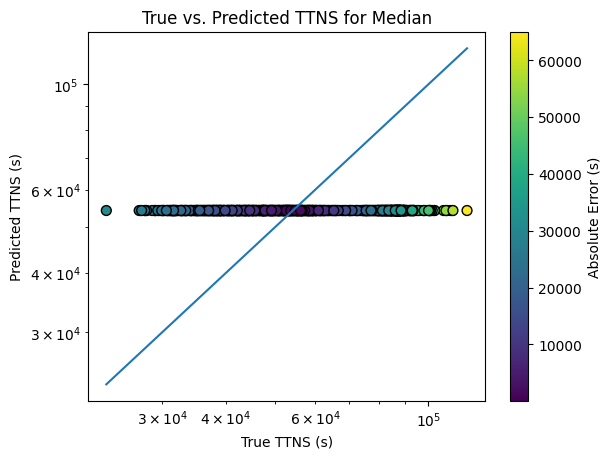

Sample0: True = 53850.00s, Predicted = 87165.00s, Error=33315.00s
Sample1: True = 58680.00s, Predicted = 53850.00s, Error=4830.00s
Sample2: True = 44400.00s, Predicted = 58680.00s, Error=14280.00s
Sample3: True = 51975.00s, Predicted = 44400.00s, Error=7575.00s
Sample4: True = 89700.00s, Predicted = 51975.00s, Error=37725.00s
Sample5: True = 84960.00s, Predicted = 89700.00s, Error=4740.00s
Sample6: True = 44625.00s, Predicted = 84960.00s, Error=40335.00s
Sample7: True = 41040.00s, Predicted = 44625.00s, Error=3585.00s
Sample8: True = 59085.00s, Predicted = 41040.00s, Error=18045.00s
Sample9: True = 32670.00s, Predicted = 59085.00s, Error=26415.00s
Sample10: True = 49545.00s, Predicted = 32670.00s, Error=16875.00s
Sample11: True = 51585.00s, Predicted = 49545.00s, Error=2040.00s
Sample12: True = 93690.00s, Predicted = 51585.00s, Error=42105.00s
Sample13: True = 47625.00s, Predicted = 93690.00s, Error=46065.00s
Sample14: True = 40530.00s, Predicted = 47625.00s, Error=7095.00s
Sample15: T

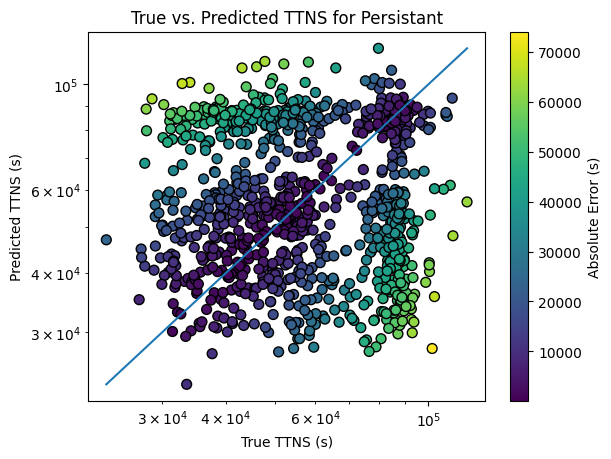

In [16]:
# Baseline Analysis:Median

y_test_secs = y_test #Taking it out of log scale
y_pred_secs = y_predicted_median

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Median")
plt.xscale('log')
plt.yscale('log')
plt.show()

#Persistnat 
y_test_secs = y_test[1:] #Taking it out of log scale
y_pred_secs = y_predicted_presist

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Persistant")
plt.xscale('log')
plt.yscale('log')
plt.show()